# Notebook 01 - Historia de los Transformers

## Objetivos
- Comprender la evolucion del NLP desde reglas hasta Transformers.
- Identificar limitaciones de RNN/LSTM frente a secuencias largas.
- Reconocer aportes clave del paper *Attention Is All You Need*.

## Introduccion
Antes de 2017, el NLP dependia de redes recurrentes que procesaban el texto token a token. Eso generaba cuellos de botella de memoria y dificultad para capturar dependencias lejanas. Este notebook recorre esa historia con datos y una linea de tiempo interactiva.

In [1]:
# Importamos librerias para tablas y graficos
from pathlib import Path
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

# Definimos la ruta base del proyecto
BASE = Path('..')
print('Entorno listo para el notebook 01')

Entorno listo para el notebook 01


## 1) Linea de tiempo del NLP
La siguiente tabla resume hitos desde enfoques simbolicos hasta modelos fundacionales actuales.

In [2]:
# Construimos un DataFrame con eventos historicos relevantes
eventos = [
    {'anio': 1950, 'hito': 'Turing y computacion simbolica', 'paradigma': 'Reglas'},
    {'anio': 1990, 'hito': 'Modelos estadisticos n-gram', 'paradigma': 'Estadistica'},
    {'anio': 2010, 'hito': 'Word2Vec y embeddings densos', 'paradigma': 'Embeddings'},
    {'anio': 2014, 'hito': 'Seq2Seq con LSTM + atencion', 'paradigma': 'RNN'},
    {'anio': 2017, 'hito': 'Attention Is All You Need', 'paradigma': 'Transformer'},
    {'anio': 2018, 'hito': 'BERT (encoder-only)', 'paradigma': 'Preentrenamiento'},
    {'anio': 2019, 'hito': 'GPT-2 (decoder-only)', 'paradigma': 'Generacion'},
    {'anio': 2020, 'hito': 'T5 texto-a-texto', 'paradigma': 'Unificacion'},
    {'anio': 2023, 'hito': 'LLMs conversacionales a escala', 'paradigma': 'Fundacionales'},
]
df_eventos = pd.DataFrame(eventos)
display(df_eventos)

,anio,hito,paradigma
0,1950,Turing y computacion simbolica,Reglas
1,1990,Modelos estadisticos n-gram,Estadistica
2,2010,Word2Vec y embeddings densos,Embeddings
3,2014,Seq2Seq con LSTM + atencion,RNN
4,2017,Attention Is All You Need,Transformer
5,2018,BERT (encoder-only),Preentrenamiento
6,2019,GPT-2 (decoder-only),Generacion
7,2020,T5 texto-a-texto,Unificacion
8,2023,LLMs conversacionales a escala,Fundacionales


## 2) Problemas de RNN y LSTM
Las redes recurrentes mantienen un estado oculto que se actualiza secuencialmente. Eso implica vanishing gradient, dificultad con dependencias largas y poca paralelizacion.

In [3]:
# Simulamos tiempos relativos de procesamiento por longitud de secuencia
import numpy as np

longitudes = np.array([10, 50, 100, 200, 500])
# Tiempo proporcional a la longitud (procesamiento secuencial)
tiempo_rnn = longitudes * 1.0
# Transformer procesa en paralelo; el costo crece pero con mejor escalado
tiempo_transformer = np.log(longitudes + 1) * 15

comparacion = pd.DataFrame({
    'longitud_tokens': longitudes,
    'costo_relativo_rnn': tiempo_rnn,
    'costo_relativo_transformer': tiempo_transformer.round(2),
})
display(comparacion)

,longitud_tokens,costo_relativo_rnn,costo_relativo_transformer
0,10,10.0,35.97
1,50,50.0,58.98
2,100,100.0,69.23
3,200,200.0,79.55
4,500,500.0,93.25


## 3) Datos clave del paper de 2017
El articulo *Attention Is All You Need* (Vaswani et al.) propuso reemplazar recurrencia por mecanismos de atencion multi-cabeza.

In [4]:
# Recopilamos hechos tecnicos del paper original
paper_facts = pd.DataFrame([
    {'concepto': 'Arquitectura base', 'detalle': 'Encoder-Decoder con Self-Attention'},
    {'concepto': 'Complejidad por capa', 'detalle': 'O(n^2 * d) respecto a longitud n'},
    {'concepto': 'Positional Encoding', 'detalle': 'Senos y cosenos para orden'},
    {'concepto': 'Multi-Head Attention', 'detalle': 'Varias cabezas en paralelo'},
    {'concepto': 'BLEU WMT 2014 EN-DE', 'detalle': '28.4 (state of the art en su epoca)'},
    {'concepto': 'Entrenamiento', 'detalle': 'Altamente paralelizable en GPU/TPU'},
])
display(paper_facts)

,concepto,detalle
0,Arquitectura base,Encoder-Decoder con Self-Attention
1,Complejidad por capa,O(n^2 * d) respecto a longitud n
2,Positional Encoding,Senos y cosenos para orden
3,Multi-Head Attention,Varias cabezas en paralelo
4,BLEU WMT 2014 EN-DE,28.4 (state of the art en su epoca)
5,Entrenamiento,Altamente paralelizable en GPU/TPU


## 4) Visualizacion interactiva de la evolucion

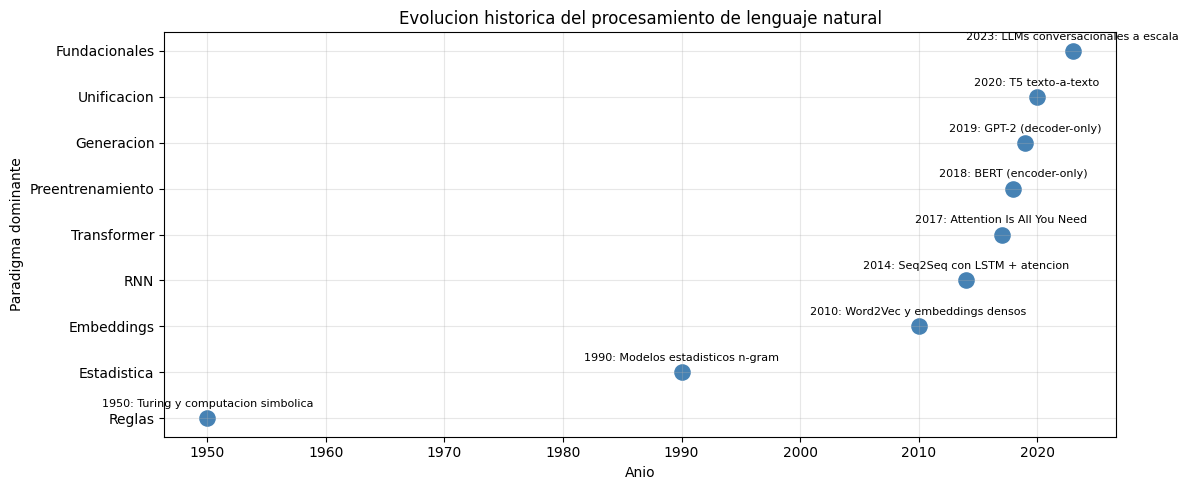

In [4]:
# Graficamos la linea de tiempo con pandas y matplotlib
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(df_eventos['anio'], df_eventos['paradigma'], s=120, c='steelblue')

# Etiquetamos cada punto con el hito principal
for _, row in df_eventos.iterrows():
    ax.annotate(
        f"{row['anio']}: {row['hito']}",
        (row['anio'], row['paradigma']),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=8,
    )

ax.set_xlabel('Anio')
ax.set_ylabel('Paradigma dominante')
ax.set_title('Evolucion historica del procesamiento de lenguaje natural')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Resultados
Obtuvimos una tabla cronologica, una comparacion cualitativa RNN vs Transformer y un grafico de evolucion del paradigma dominante.

## Conclusiones
Los Transformers surgieron como respuesta directa a limitaciones de RNN/LSTM. Su paralelizacion y atencion global cambiaron el ritmo de innovacion en NLP.

## Ejercicios guiados resueltos
**Ejercicio 1:** Agrega un evento de 2024 relacionado con modelos abiertos.

**Solucion:**

In [6]:
# Agregamos una fila nueva al DataFrame de eventos
nuevo = pd.DataFrame([{
    'anio': 2024,
    'hito': 'Modelos open-weight de alta eficiencia',
    'paradigma': 'Fundacionales',
}])
df_actualizado = pd.concat([df_eventos, nuevo], ignore_index=True)
display(df_actualizado.tail(3))

,anio,hito,paradigma
7,2020,T5 texto-a-texto,Unificacion
8,2023,LLMs conversacionales a escala,Fundacionales
9,2024,Modelos open-weight de alta eficiencia,Fundacionales


## Ejercicios propuestos
1. Investiga que problema resolvio Word2Vec que n-gram no resolvia bien.
2. Compara BLEU de Seq2Seq clasicos vs Transformer en traduccion.
3. Elabora un diagrama de arquitectura encoder-decoder sin usar recurrencia.

## Preguntas de reflexion
1. Por que la atencion global es costosa en secuencias muy largas?
2. Que ventaja aporta el preentrenamiento mas alla de la arquitectura?
3. En que tareas aun pueden ser utiles modelos mas pequenos que un LLM?